<a href="https://colab.research.google.com/github/Aarya718/VOIS-INTERNSHIP/blob/main/Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Major Project: Seasonal Agriculture Performance Analysis

**VOIS AICTE Batch 1 (2026–2027)**

**NAME : AARYA RAMCHANDRA TARPHE**

**AICTE STUDENT ID : STU66595b86dc18b1717132166**



##Project aim
This notebook studies how agricultural performance changes across **Kharif, Rabi and Zaid** seasons. The analysis focuses on yield, production, costs, revenue, profit, water use, environmental conditions, crop differences and regional patterns.

The project brief asks us to explore and clean the data, compare seasons, investigate relationships, identify unusual patterns, use suitable statistics and visualizations, and finish with evidence-based conclusions and recommendations.

## Analytical questions

I used the project brief to turn the broad problem into a set of practical questions:

1. How many records and variables are present, and what does each variable represent?
2. Is the dataset complete, or are there missing values?
3. How does yield vary across the three seasons?
4. How do revenue, cost and profit change by season?
5. Do crops behave differently across seasons?
6. Are resource-use measures such as fertilizer, irrigation and water use different across seasons?
7. What is the relationship between environmental conditions and agricultural outcomes?
8. Does irrigation method appear to be associated with yield, profit and water efficiency?
9. Are some states or regions performing differently?
10. Are there unusual observations that need to be kept in mind while interpreting the results?
11. What practical conclusions and recommendations can be made from the data?

These questions directly cover the areas suggested in the project instructions: seasonal patterns, resource usage, environmental conditions, economic outcomes, regional consistency and unusual observations.

In [1]:
# Import the libraries used in the analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load the dataset

If this notebook is opened in Google Colab, upload the CSV when prompted. If the CSV is already in the notebook's working directory, the second option will load it directly.

In [3]:
# Load the CSV file
import os

file_name = "seasonal_agriculture_performance_dataset (2).csv"

if not os.path.exists(file_name):
    from google.colab import files
    uploaded = files.upload()
    file_name = next(iter(uploaded))

df = pd.read_csv(file_name)

print("Dataset loaded.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()

Dataset loaded.
Rows: 4000
Columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


## 2. First look at the data

Before calculating anything, I checked the structure, data types and basic summary statistics. This helps avoid making assumptions about the variables.

In [4]:
# Structure and data types
df.info()

print("\nFirst five rows:")
display(df.head())

print("\nNumber of unique values:")
display(df.nunique().sort_values(ascending=False).to_frame("unique_values").head(15))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30



Number of unique values:


,unique_values
Farm_ID,4000
Total_Cost_INR,3995
Revenue_INR,3993
Profit_INR,3992
Market_Price_INR_Tonne,3760
Water_Used_m3,3407
Rainfall_mm,3256
Water_Efficiency_t_per_1000m3,3127
Production_Tonnes,2528
Fertilizer_kg_ha,1881


In [5]:
# Descriptive statistics for numerical columns
display(df.describe().T)

# Category counts
for col in ["Season", "Crop", "Irrigation_Method"]:
    print(f"\n{col} distribution:")
    display(df[col].value_counts().to_frame("count"))

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"3,960.00",26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00



Season distribution:


,count
Season,
Kharif,1779
Rabi,1627
Zaid,594



Crop distribution:


,count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305



Irrigation_Method distribution:


,count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


## 3. Data quality check

The main cleaning checks are missing values, duplicated rows and obviously invalid numeric values. I am not removing observations just because they look large; an unusual value may still be a genuine farm observation.

In [6]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_count"))

print("Total missing cells:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

# Simple range checks
range_checks = {
    "Farm_Area_Hectares": df["Farm_Area_Hectares"].min() >= 0,
    "Soil_pH": df["Soil_pH"].between(0, 14, inclusive="both").all(),
    "Humidity_pct": df["Humidity_pct"].between(0, 100, inclusive="both").all(),
    "Soil_Moisture_pct": df["Soil_Moisture_pct"].between(0, 100, inclusive="both").all(),
    "Disease_Pest_Risk_pct": df["Disease_Pest_Risk_pct"].between(0, 100, inclusive="both").all(),
}

print("\nBasic range checks:")
display(pd.Series(range_checks, name="passes_check"))

,missing_count
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


Total missing cells: 120
Duplicate rows: 0

Basic range checks:


,passes_check
Farm_Area_Hectares,True
Soil_pH,True
Humidity_pct,True
Soil_Moisture_pct,False
Disease_Pest_Risk_pct,True


### Cleaning approach

There are missing values in **Rainfall_mm, Soil_Moisture_pct and Yield_Tonnes_Ha**. Instead of filling every missing value blindly, the analysis below uses the available observations for each calculation. This is particularly important for yield because yield is one of the main outcomes of the project. For relationships that require complete numeric columns, rows are selected only for the variables involved.

In [7]:
# Create a clean copy and remove exact duplicate rows if any exist.
# No duplicates are expected, but this makes the cleaning step explicit.
clean_df = df.drop_duplicates().copy()

print("Original rows:", len(df))
print("Rows after duplicate check:", len(clean_df))
print("Rows removed:", len(df) - len(clean_df))

Original rows: 4000
Rows after duplicate check: 4000
Rows removed: 0


## 4. Seasonal composition

The first comparison is simply the number of farms represented in each season. A difference in sample size is important when reading later averages.

,farm_records
Season,
Kharif,1779
Rabi,1627
Zaid,594


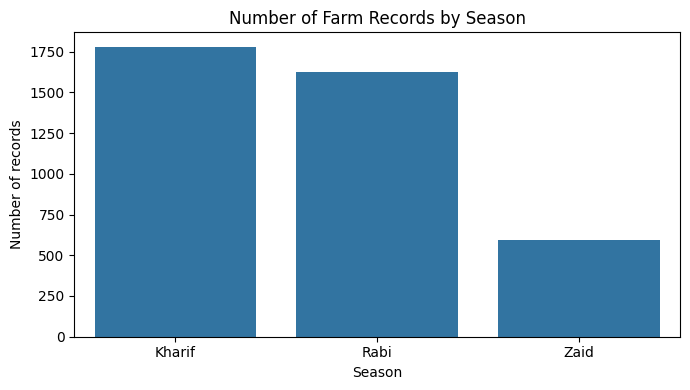

In [8]:
season_counts = clean_df["Season"].value_counts().reindex(["Kharif", "Rabi", "Zaid"])
display(season_counts.to_frame("farm_records"))

plt.figure(figsize=(7, 4))
sns.barplot(x=season_counts.index, y=season_counts.values)
plt.title("Number of Farm Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()

## 5. Question 1 — How does agricultural performance vary across seasons?

For a broad performance comparison, I looked at yield, revenue, total cost, profit and water efficiency. Mean values are useful for an overall comparison, while the median profit is also shown because profit has some very large values.

In [9]:
season_summary = clean_df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Median_Yield=("Yield_Tonnes_Ha", "median"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Cost=("Total_Cost_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Median_Profit=("Profit_INR", "median"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Disease_Risk=("Disease_Pest_Risk_pct", "mean")
).reindex(["Kharif", "Rabi", "Zaid"])

display(season_summary.round(2))

,Records,Avg_Yield,Median_Yield,Avg_Revenue,Avg_Cost,Avg_Profit,Median_Profit,Avg_Water_Efficiency,Avg_Disease_Risk
Season,,,,,,,,,
Kharif,1779,5.64,1.95,"710,719.06","531,804.41","178,914.65","38,808.00",5.89,54.47
Rabi,1627,5.08,1.66,"601,526.05","513,836.58","87,689.47","-3,187.00",5.19,40.48
Zaid,594,4.67,1.45,"519,171.90","543,976.73","-24,804.82","-62,144.00",4.41,38.22


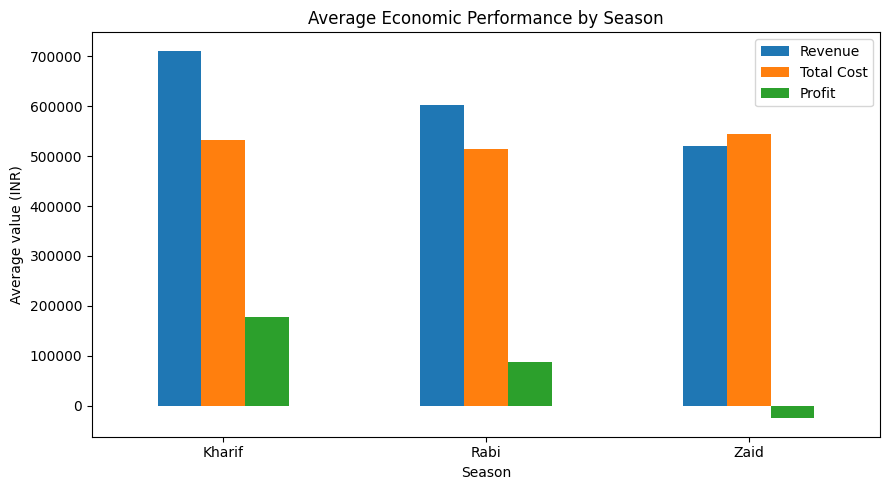

In [10]:
# Compare the main economic measures visually
economic_long = clean_df.groupby("Season")[["Revenue_INR", "Total_Cost_INR", "Profit_INR"]].mean().reindex(
    ["Kharif", "Rabi", "Zaid"]
)

economic_long.plot(kind="bar", figsize=(9, 5))
plt.title("Average Economic Performance by Season")
plt.xlabel("Season")
plt.ylabel("Average value (INR)")
plt.xticks(rotation=0)
plt.legend(["Revenue", "Total Cost", "Profit"])
plt.tight_layout()
plt.show()

### Observation

Kharif has the strongest average yield and economic performance in this dataset. Rabi is positive on average but lower than Kharif, while Zaid has the lowest average yield and a negative average profit. This does not mean that every Kharif farm is more profitable; it is a statement about the average pattern in the available records.

## 6. Question 2 — Are seasonal differences statistically noticeable?

A one-way ANOVA is used as a simple check of whether the **mean** values differ across the three seasons. The test does not explain why the seasons differ, and it should not be treated as proof of causation.

In [11]:
# One-way ANOVA for selected outcomes
anova_results = []

for metric in ["Yield_Tonnes_Ha", "Profit_INR", "Revenue_INR", "Water_Efficiency_t_per_1000m3"]:
    groups = [
        group[metric].dropna()
        for _, group in clean_df.groupby("Season")
    ]
    statistic, p_value = f_oneway(*groups)
    anova_results.append([metric, statistic, p_value])

anova_table = pd.DataFrame(anova_results, columns=["Metric", "F_statistic", "p_value"])
display(anova_table)

print("\nInterpretation rule used here: p < 0.05 indicates evidence that at least one seasonal mean differs.")

,Metric,F_statistic,p_value
0,Yield_Tonnes_Ha,1.46,0.23
1,Profit_INR,34.29,0.00
2,Revenue_INR,24.89,0.00
3,Water_Efficiency_t_per_1000m3,6.95,0.00



Interpretation rule used here: p < 0.05 indicates evidence that at least one seasonal mean differs.


### Interpretation

The test gives a useful distinction between the measures. Seasonal differences are much clearer for **profit, revenue and water efficiency** than for yield. In other words, the seasonal gap in average yield is not statistically strong enough at the 5% level in this sample, while the economic and water-efficiency measures show stronger evidence of differences.

The statistical result should be read together with the plots and group summaries rather than by p-value alone.

## 7. Question 3 — What changes between seasons in terms of environment and resource use?

The next step is to compare rainfall, temperature, soil moisture, fertilizer and water use. These variables help describe the conditions under which the farms operated.

In [12]:
resource_summary = clean_df.groupby("Season").agg(
    Rainfall_mm=("Rainfall_mm", "mean"),
    Temperature_C=("Avg_Temperature_C", "mean"),
    Humidity_pct=("Humidity_pct", "mean"),
    Soil_Moisture_pct=("Soil_Moisture_pct", "mean"),
    Fertilizer_kg_ha=("Fertilizer_kg_ha", "mean"),
    Pesticide_Litre_ha=("Pesticide_Litre_ha", "mean"),
    Water_Used_m3=("Water_Used_m3", "mean"),
    Nitrogen_kg_ha=("Nitrogen_kg_ha", "mean"),
    Phosphorus_kg_ha=("Phosphorus_kg_ha", "mean"),
    Potassium_kg_ha=("Potassium_kg_ha", "mean")
).reindex(["Kharif", "Rabi", "Zaid"])

display(resource_summary.round(2))

,Rainfall_mm,Temperature_C,Humidity_pct,Soil_Moisture_pct,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha
Season,,,,,,,,,,
Kharif,852.08,28.45,71.81,31.20,187.08,5.08,"6,102.20",120.02,58.10,105.30
Rabi,436.00,23.49,57.89,24.05,185.41,5.02,"5,846.99",120.40,57.31,103.93
Zaid,299.42,31.04,52.01,19.17,184.64,5.17,"6,419.89",120.53,58.13,105.42


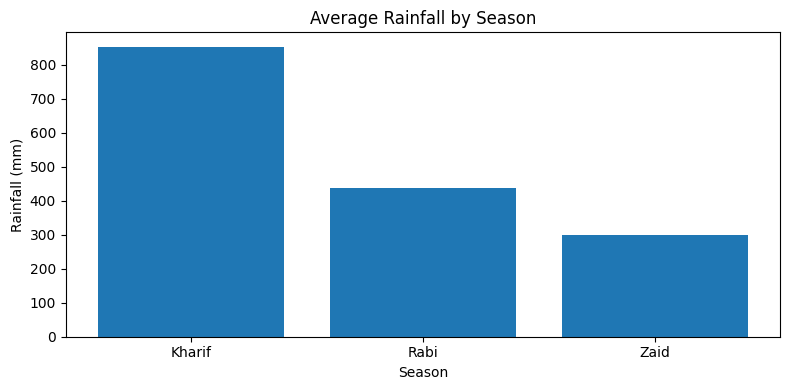

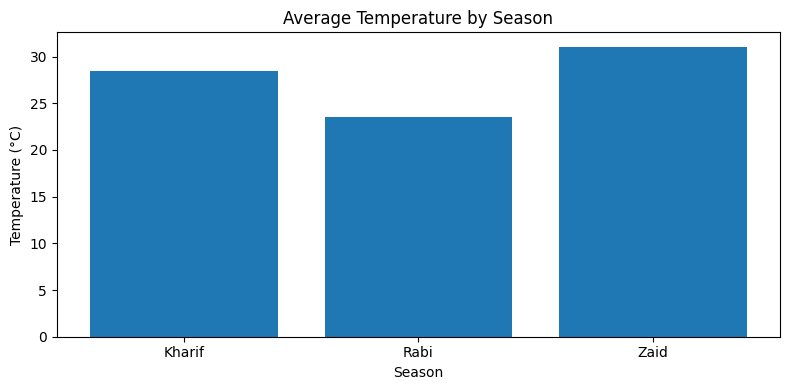

In [13]:
# Rainfall and temperature across seasons
fig, ax = plt.subplots(figsize=(8, 4))
season_order = ["Kharif", "Rabi", "Zaid"]

rain = clean_df.groupby("Season")["Rainfall_mm"].mean().reindex(season_order)
ax.bar(season_order, rain.values)
ax.set_title("Average Rainfall by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Rainfall (mm)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
temp = clean_df.groupby("Season")["Avg_Temperature_C"].mean().reindex(season_order)
ax.bar(season_order, temp.values)
ax.set_title("Average Temperature by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

### Observation

Rainfall is highest in Kharif and falls substantially in Rabi and Zaid. The seasonal difference in rainfall is therefore much more pronounced than the difference in temperature. This provides useful context when interpreting irrigation and water-use results.

## 8. Question 4 — Do crops behave differently across seasons?

A season-only average can hide crop effects. I therefore compare average profit for each crop within each season. Missing combinations are left blank rather than being treated as zero.

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,"954,380.00","638,572.00","448,659.00"
Cotton,"217,000.00","107,344.00","-53,925.00"
Groundnut,"108,265.00","10,417.00","-68,872.00"
Maize,"-39,333.00","-89,133.00","-194,049.00"
Pulses,"43,339.00","-14,309.00","-139,228.00"
Rice,"-64,903.00","-98,428.00","-227,239.00"
Sugarcane,"1,000,791.00","731,613.00","583,636.00"
Wheat,"-105,872.00","-119,955.00","-193,209.00"


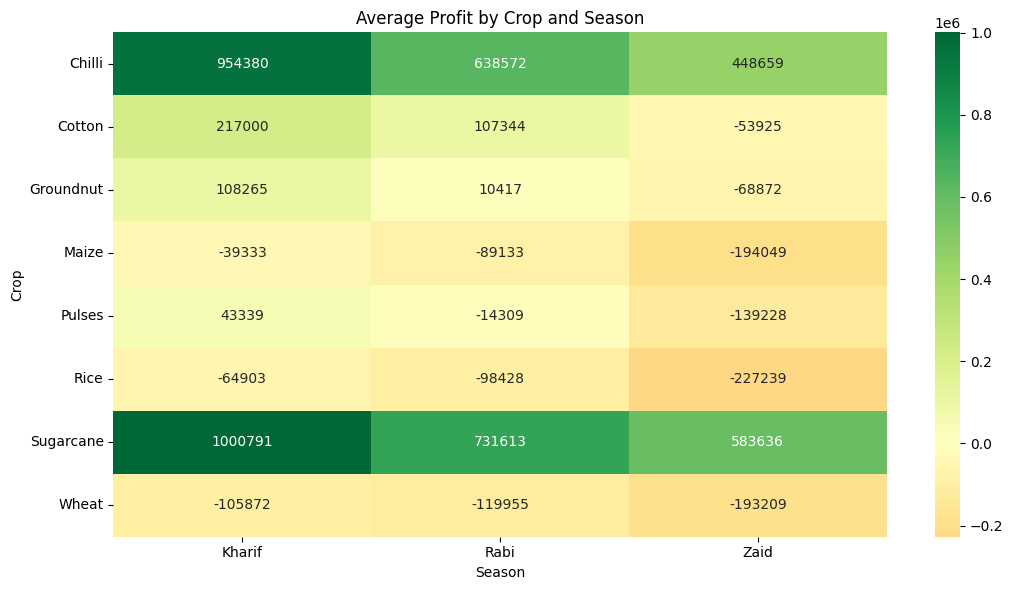

In [14]:
crop_season_profit = clean_df.pivot_table(
    index="Crop",
    columns="Season",
    values="Profit_INR",
    aggfunc="mean"
)

crop_season_profit = crop_season_profit.reindex(columns=["Kharif", "Rabi", "Zaid"])
display(crop_season_profit.round(0))

plt.figure(figsize=(11, 6))
sns.heatmap(crop_season_profit, annot=True, fmt=".0f", cmap="RdYlGn", center=0)
plt.title("Average Profit by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

### Observation

The crop-level table shows that seasonal performance is not uniform across crops. Chilli and Sugarcane have much stronger average profits than several other crops, while crops such as Rice and Maize show weaker average profitability in this dataset. Therefore, it would be too simple to say that the season alone determines performance.

## 9. Question 5 — Is irrigation method related to performance?

Irrigation is especially relevant when comparing seasons because rainfall availability changes. Here I compare yield, profit and water efficiency by irrigation method. This is an association, not a causal experiment.

In [15]:
irrigation_summary = clean_df.groupby("Irrigation_Method").agg(
    Records=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Water_Used=("Water_Used_m3", "mean")
).sort_values("Avg_Profit", ascending=False)

display(irrigation_summary.round(2))

,Records,Avg_Yield,Avg_Profit,Avg_Water_Efficiency,Avg_Water_Used
Irrigation_Method,,,,,
Drip,915,6.62,"219,626.00",6.27,"5,918.75"
Sprinkler,734,5.19,"91,121.08",4.67,"6,208.26"
Rainfed,1041,4.61,"79,050.37",7.56,"3,549.55"
Flood,1310,4.90,"73,354.02",3.44,"8,026.47"


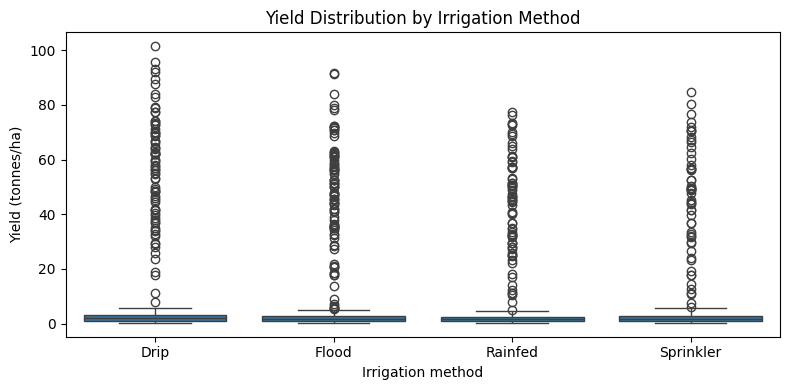

In [16]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=clean_df, x="Irrigation_Method", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution by Irrigation Method")
plt.xlabel("Irrigation method")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

### Observation

Drip irrigation has the highest average yield and profit among the listed methods. Rainfed farming has the highest average water-efficiency value, which is reasonable because the efficiency measure and water use are calculated differently for rain-dependent farms. These results should therefore be interpreted as patterns in the dataset rather than proof that changing irrigation alone would create the same outcome everywhere.

## 10. Question 6 — Which states show higher average profitability?

The dataset covers multiple Indian states. A state-level comparison can reveal whether the seasonal pattern is consistent across geographical areas.

In [ ]:
state_summary = clean_df.groupby("State").agg(
    Records=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean")
).sort_values("Avg_Profit", ascending=False)

display(state_summary.round(2))

plt.figure(figsize=(10, 5))
sns.barplot(
    data=state_summary.reset_index(),
    x="Avg_Profit",
    y="State"
)
plt.title("Average Profit by State")
plt.xlabel("Average profit (INR)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

### Observation

Punjab and Maharashtra have the highest average profits in the state comparison, while Andhra Pradesh has the lowest average profit. The difference suggests that location-related factors are worth considering alongside season, crop and farming practices.

## 11. Question 7 — Are environmental variables related to agricultural outcomes?

Correlation is used here to see whether numerical variables move together. Correlation does **not** establish cause and effect. Also, missing values are handled pairwise by pandas in the correlation calculation.

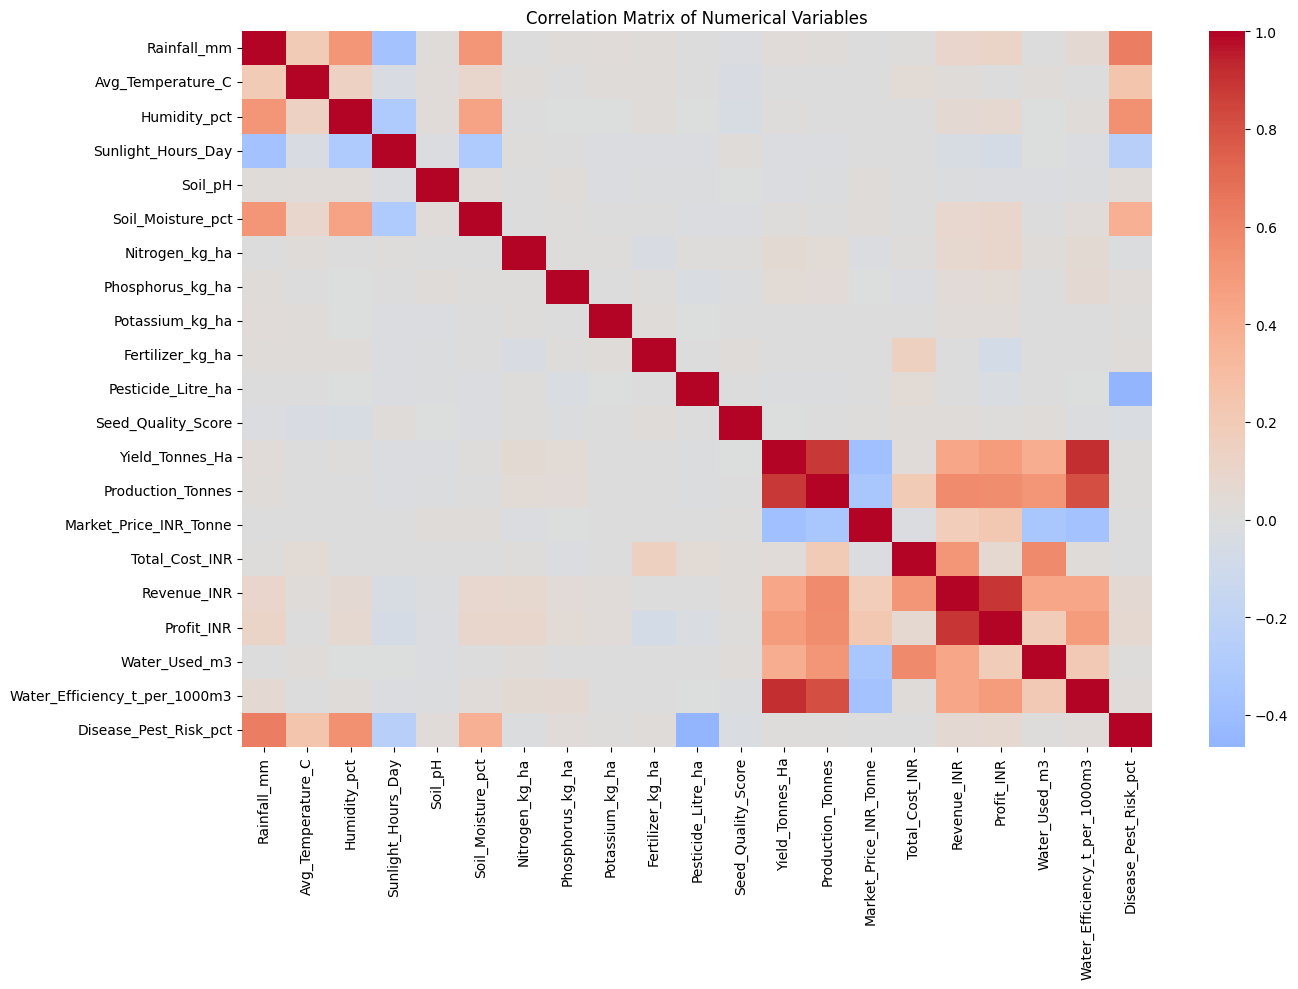

Correlations with Profit:


,correlation
Profit_INR,1.00
Revenue_INR,0.89
Production_Tonnes,0.55
Yield_Tonnes_Ha,0.49
Water_Efficiency_t_per_1000m3,0.49
Market_Price_INR_Tonne,0.23
Water_Used_m3,0.19
Rainfall_mm,0.11
Soil_Moisture_pct,0.09
Nitrogen_kg_ha,0.09


In [17]:
numeric_cols = [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Sunlight_Hours_Day", "Soil_pH", "Soil_Moisture_pct",
    "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
    "Fertilizer_kg_ha", "Pesticide_Litre_ha", "Seed_Quality_Score",
    "Yield_Tonnes_Ha", "Production_Tonnes", "Market_Price_INR_Tonne",
    "Total_Cost_INR", "Revenue_INR", "Profit_INR",
    "Water_Used_m3", "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

corr = clean_df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

print("Correlations with Profit:")
display(corr["Profit_INR"].sort_values(ascending=False).to_frame("correlation"))

### Interpretation

Profit has a strong positive relationship with revenue, which is expected because revenue is one of the main components of profit. Production and yield are also connected to several performance measures. Environmental variables show weaker and more mixed relationships, suggesting that agricultural performance is influenced by several factors rather than a single condition.

## 12. Question 8 — Are there unusual observations?

Large farms naturally have larger production, revenue and cost values, so a high value is not automatically an error. I use the IQR rule only as a screening tool to understand the spread of key variables.

In [18]:
def iqr_outlier_count(series):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return int(((s < lower) | (s > upper)).sum()), lower, upper

outlier_rows = []
for col in ["Yield_Tonnes_Ha", "Production_Tonnes", "Revenue_INR", "Profit_INR", "Water_Used_m3"]:
    count, lower, upper = iqr_outlier_count(clean_df[col])
    outlier_rows.append([col, count, lower, upper])

outlier_table = pd.DataFrame(
    outlier_rows,
    columns=["Variable", "IQR_flagged_rows", "Lower_limit", "Upper_limit"]
)

display(outlier_table.round(2))

,Variable,IQR_flagged_rows,Lower_limit,Upper_limit
0,Yield_Tonnes_Ha,302,-1.63,5.52
1,Production_Tonnes,333,-23.98,53.36
2,Revenue_INR,240,"-736,519.00","1,780,911.00"
3,Profit_INR,404,"-696,111.00","763,567.00"
4,Water_Used_m3,276,"-6,072.75","16,171.25"


### Observation

The data contains some high-value observations, especially for production, revenue and profit. These may partly come from differences in farm area and crop type. I have therefore kept them in the main analysis instead of deleting them automatically.

## 13. A closer look at farm size and production

Production is affected by both yield per hectare and farm area. Checking the relationship helps explain why production can vary much more than yield.

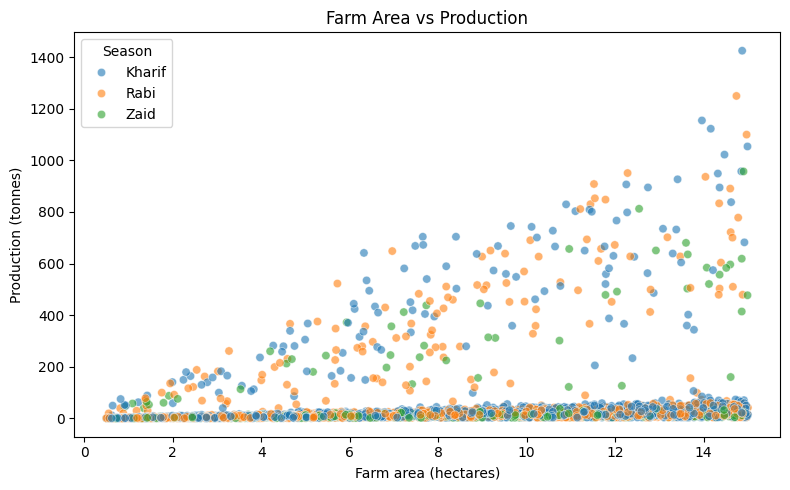

Correlation between farm area and production: 0.198


In [19]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=clean_df,
    x="Farm_Area_Hectares",
    y="Production_Tonnes",
    hue="Season",
    alpha=0.6
)
plt.title("Farm Area vs Production")
plt.xlabel("Farm area (hectares)")
plt.ylabel("Production (tonnes)")
plt.tight_layout()
plt.show()

print("Correlation between farm area and production:",
      clean_df[["Farm_Area_Hectares", "Production_Tonnes"]].corr().iloc[0, 1].round(3))

## 14. Seasonal profitability distribution

Averages can hide loss-making farms. The box plot below shows the spread of profit and makes it easier to see whether each season contains both profitable and loss-making observations.

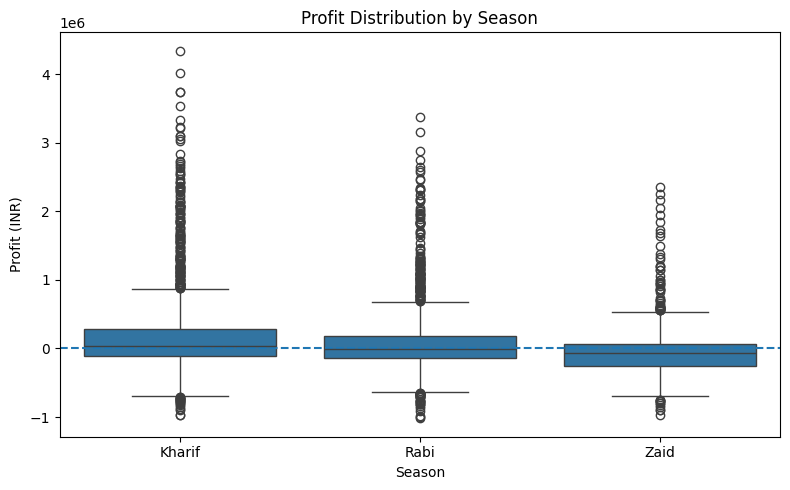

,Loss_making_records_percent
Season,
Kharif,42.21
Rabi,51.14
Zaid,64.48


In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=clean_df, x="Season", y="Profit_INR", order=["Kharif", "Rabi", "Zaid"])
plt.axhline(0, linestyle="--")
plt.title("Profit Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

# Percentage of loss-making records by season
loss_rate = (
    clean_df.assign(Loss=clean_df["Profit_INR"] < 0)
    .groupby("Season")["Loss"]
    .mean()
    .reindex(["Kharif", "Rabi", "Zaid"])
    * 100
)

display(loss_rate.round(2).to_frame("Loss_making_records_percent"))

## 15. Final findings

Based on the calculations above, the main points are:

- **Kharif performs best on average** for yield, revenue and profit in the available records.
- **Zaid is the weakest season economically**, with negative average profit and lower average yield.
- Seasonal differences are statistically clearer for **profit, revenue and water efficiency** than for yield.
- **Rainfall differs strongly by season**, with Kharif receiving the highest average rainfall.
- Crop choice matters. The crop-by-season table shows that some crops remain profitable across seasons while others are much weaker.
- **Drip irrigation** has the highest average yield and profit among the irrigation methods in this dataset.
- State-level results vary substantially, so seasonal planning should not be identical for every region.
- Some extreme observations exist, but they were retained because they may represent genuine differences in farm size, crop or production.
- Correlation results show that agricultural performance is connected to multiple factors; a single environmental variable does not explain the whole picture.

## 16. Recommendations

1. **Plan seasonal crop choices carefully.** The stronger average Kharif performance suggests that crop selection and resource allocation should consider the seasonal conditions rather than using one common plan throughout the year.

2. **Give extra attention to Zaid economics.** Since average profit is negative, farmers and planners should examine input costs, expected market prices, irrigation requirements and crop selection before increasing cultivation in this season.

3. **Use irrigation according to local conditions.** Drip irrigation shows strong average performance in this dataset, but the correct choice should also consider installation cost, water availability and crop requirements.

4. **Use region-specific planning.** The state comparison shows that performance varies by location, so recommendations should be adapted to local soil, weather, crop and market conditions.

5. **Track water efficiency, not only yield.** A high yield is useful, but water use should also be considered when comparing farming practices.

6. **Monitor profitability rather than production alone.** A crop can produce a reasonable yield but still produce a weak financial result when costs are high or market prices are low.

7. **Collect more complete data.** Missing rainfall, soil-moisture and yield values limit some comparisons. Better data recording would make future seasonal analysis more reliable.

## 17. Conclusion

The analysis shows clear differences in agricultural performance between seasons, particularly in economic outcomes and water efficiency. Kharif has the strongest overall performance in this dataset, while Zaid faces weaker profitability. At the same time, crop, irrigation method and state also create important differences.

Therefore, the main conclusion is that **seasonal agricultural performance should be studied together with crop choice, resource use, environmental conditions and regional factors**. The dataset supports useful comparisons and planning insights, but the results describe associations in the available records and should not be interpreted as proof that one factor alone causes the observed outcomes.

## 18. Project limitations

- The dataset is observational, so causal conclusions cannot be made.
- Missing values are present in rainfall, soil moisture and yield.
- The number of records is not identical across seasons.
- Average values can hide differences between individual farms.
- Market conditions and other external factors may affect profitability but are not fully represented in the available variables.
- The project uses the supplied dataset only; conclusions should not automatically be generalized to all agricultural regions or years.